- ***Supervised Learning*** is used when data has inputs and a known output/label. Here, `TV`, `Radio`, and `Newspaper` are inputs, and `Sales` is the output, so this is supervised learning.

- ***Supervised Learning Methods:***
  - ***Regression:*** Use when the output is a number, like sales, price, or marks.
  - ***Classification:*** Use when the output is a category, like pass/fail, yes/no, or spam/not spam.

- ***Unsupervised Learning*** is used when data has no output/label. It helps find hidden patterns in data.

- ***Unsupervised Learning Methods:***
  - ***Clustering:*** Use to group similar data, like customer groups. Example: K-Means.
  - ***Dimensionality Reduction:*** Use to reduce many columns/features into fewer important ones. Example: PCA.

# **LINEAR REGRESSION**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../datasets/6 advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


- ***Check For Linearity in Dataset***

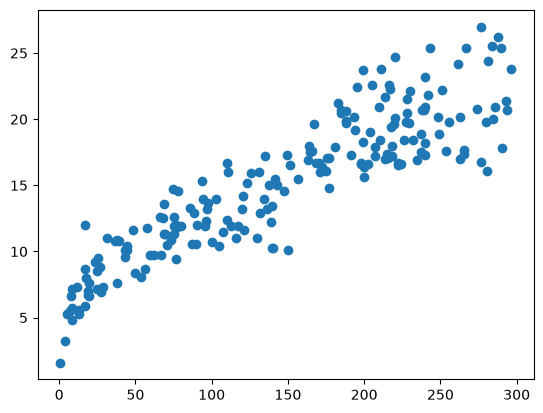

In [3]:
plt.scatter(x = df['TV'], y = df['Sales'])

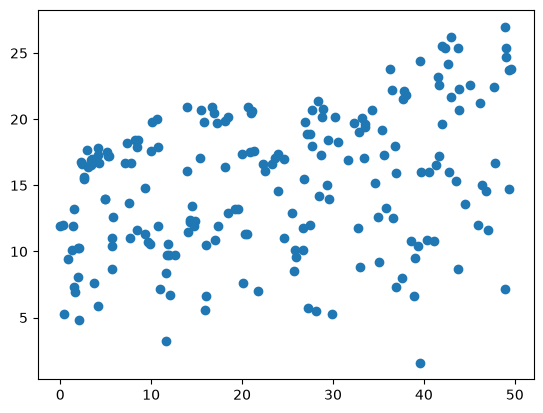

In [4]:
plt.scatter(x = df['Radio'], y = df['Sales'])

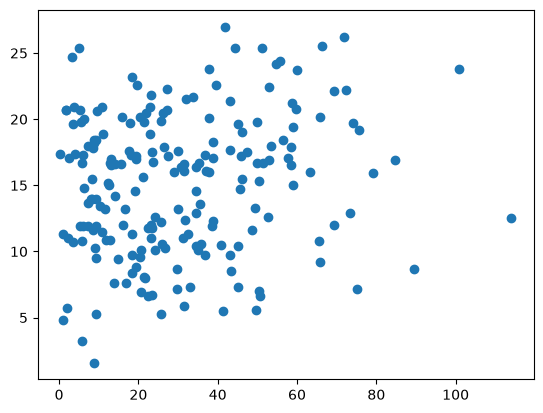

In [5]:
plt.scatter(x = df['Newspaper'], y = df['Sales'])

 # **Train Test Split**

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X = df.drop('Sales', axis=1)
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((160, 3), (40, 3), (160,), (40,))

# ***Applying Linear Regression***

In [9]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

- ***Training model***

In [10]:
lr.fit(X_train, y_train) #Training the model on 80% input data and output data

y_pred = lr.predict(X_test) #Making predictions on the remaining 20% input data

In [11]:
y_pred

array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879,
       12.56940161, 21.08119452,  8.69035045, 17.23701254, 16.66657475,
        8.92396497,  8.4817344 , 18.2075123 ,  8.06750728, 12.64550975,
       14.93162809,  8.12814594, 17.89876565, 11.00880637, 20.47832788,
       20.80631846, 12.59883297, 10.9051829 , 22.38854775,  9.41796094,
        7.92506736, 20.83908497, 13.81520938, 10.77080925,  7.92682509,
       15.95947357, 10.63490851, 20.80292008, 10.43434164, 21.5784752 ,
       21.18364487, 12.12821771, 22.80953262, 12.60992766,  6.46441252])

# ***Metrics R2 Score***

In [12]:
from sklearn.metrics import r2_score, mean_absolute_error

In [13]:
mean_absolute_error(y_test, y_pred) 
# we use the data which model has not seen before to check the accuracy of the model. This is called testing the model. The mean absolute error is the average of the absolute errors between the predicted and actual values. The lower the mean absolute error, the better the model's performance.

1.2748262109549338

In [14]:
r2_score(y_test, y_pred)

0.9059011844150826

# **Predictive System**

In [18]:
df.iloc[0]

TV           230.1
Radio         37.8
Newspaper     69.2
Sales         22.1
Name: 0, dtype: float64

In [19]:
def predict_sales(tv_budget, radio_budget, newspaper_budget):
    features = np.array([[tv_budget, radio_budget, newspaper_budget]])
    results =lr.predict(features).reshape(1, -1 )
    return results[0]

In [20]:
tv_budget = 230.1
radio_budget = 37.8
newspaper_budget = 69.2
sales = predict_sales(tv_budget, radio_budget, newspaper_budget)

/var/www/html/A.I-and-ML-Learning/Scikit-Learn/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [21]:
sales

array([21.37254028])

- **Coneverting Model in File to be used in websites**

In [22]:
import pickle

pickle.dump(lr, open('linear_model.pkl', 'wb')) #Saving the model to a file called model.pkl